# Initial exploration

In [20]:
!pip install -q python-calamine
!wget -q -O wildlife.zip "https://wildlife.faa.gov/assets/database.zip"
!unzip -o -q wildlife.zip -d data
!ls data
!apt-get -qq install -y mdbtools > /dev/null
!mdb-tables -1 data/Public.accdb

!mdb-export data/Public.accdb STRIKE_REPORTS > wildlife.csv

import pandas as pd
df = pd.read_csv("wildlife.csv", low_memory=False)
print(df.shape)
df.head()

obj_cols = df.select_dtypes(include="object").columns
df[obj_cols] = df[obj_cols].astype("string")

df.to_parquet("wildlife.parquet")
print("Saved wildlife.parquet")

readme = pd.read_excel("data/read_me.xls", engine="calamine")
readme

Public.accdb  read_me.xls
STRIKE_REPORTS
(356972, 103)
Saved wildlife.parquet


,Column Name,Explanation of Column Name and Codes
0,NaN,NaN
1,INDEX NR,Individual record number
2,OPID,Airline operator code
3,OPERATOR,A three letter International Civil Aviation Or...
4,ATYPE,Aircraft
5,AMA,International Civil Aviation Organization code...
6,AMO,International Civil Aviation Organization code...
7,EMA,Engine Make Code (see Engine Codes tab below)
8,EMO,Engine Model Code (see Engine Codes tab below)
9,AC_CLASS,Type of aircraft (see Aircraft Type tab below)


In [21]:
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

column_info = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values
})

display(column_info)

,Column Name,Data Type,Missing Values
0,INDEX_NR,int64,0
1,INCIDENT_DATE,string,0
2,INCIDENT_MONTH,int64,0
3,INCIDENT_YEAR,int64,0
4,TIME,string,121299
5,TIME_OF_DAY,string,155920
6,AIRPORT_ID,string,2
7,AIRPORT,string,0
8,AIRPORT_LATITUDE,float64,356972
9,AIRPORT_LONGITUDE,float64,356972


# Main cleaning and processing

In [22]:
# ============================================================
# FAA Wildlife Strike Dataset: Data Challenges (checks only)
# Read-only: nothing here modifies df. The cleaning pipeline
# does the actual fixes.
# ============================================================

import pandas as pd
import numpy as np

TEXT_TYPES = ["object", "string", "category"]
n_rows = len(df)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


def pct(n):
    return f"{n:,} ({n / n_rows * 100:.1f}%)"


# ------------------------------------------------------------
# Challenge 1: High missingness
# ------------------------------------------------------------
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2),
}).sort_values("Missing_Percentage", ascending=False)

print("\nTop 20 columns by missing values:")
display(missing_summary.head(20))

empty_cols = missing_summary.index[missing_summary["Missing_Percentage"] == 100].tolist()
print(f"Completely empty columns ({len(empty_cols)}): {empty_cols}")


# ------------------------------------------------------------
# Challenge 2: Hidden placeholders and inconsistent categories
# isnull() cannot see text like "UNKNOWN", so we count it here.
# ------------------------------------------------------------
categorical_columns = df.select_dtypes(include=TEXT_TYPES).columns
PLACEHOLDERS = {"", "UNKNOWN", "UNK", "N/A", "NA"}

rows = []
for c in categorical_columns:
    s = df[c].astype("string").str.strip()
    exact = int(s.str.upper().isin(PLACEHOLDERS).sum())
    partial = int(s.str.contains(r"\bUNK", case=False, na=False).sum()) - exact
    rows.append({"Column": c, "Unique values": s.nunique(),
                 "Exact placeholders": exact, "Contains 'unknown' (not exact)": partial})

placeholder_summary = (pd.DataFrame(rows).set_index("Column")
                       .sort_values("Exact placeholders", ascending=False))
print("\nPlaceholder text hidden from isnull():")
display(placeholder_summary[placeholder_summary.iloc[:, 1:].sum(axis=1) > 0])

if "SPECIES" in df.columns:
    sp = df["SPECIES"].astype("string")
    print("\nExample: 'unknown' species labels that exact matching misses:")
    display(sp[sp.str.contains("unknown", case=False, na=False)].value_counts().head(10))


# ------------------------------------------------------------
# Challenge 3: Skewed values (continuous columns only)
# ------------------------------------------------------------
continuous = [c for c in ["HEIGHT", "SPEED", "DISTANCE", "AOS",
                          "COST_REPAIRS_INFL_ADJ", "COST_OTHER_INFL_ADJ"] if c in df.columns]
summary = df[continuous].describe(percentiles=[.5, .9, .99]).T
summary["skew"] = df[continuous].skew()
summary["% zeros"] = ((df[continuous] == 0).sum() / df[continuous].notna().sum() * 100).round(1)
print("\nContinuous columns: skew and zero-inflation")
display(summary.round(1))


# ------------------------------------------------------------
# Challenge 4: Class imbalance
# ------------------------------------------------------------
if "INDICATED_DAMAGE" in df.columns:
    print("\nTarget distribution:")
    display(pd.DataFrame({
        "count": df["INDICATED_DAMAGE"].value_counts(dropna=False),
        "%": df["INDICATED_DAMAGE"].value_counts(normalize=True, dropna=False).mul(100).round(2),
    }))


# ------------------------------------------------------------
# Challenge 5: Leakage and identifier columns
# Listed here; actually dropped in pipeline step 12.
# ------------------------------------------------------------
leakage_columns = (
    ["DAMAGE_LEVEL", "COST_REPAIRS", "COST_OTHER", "COST_REPAIRS_INFL_ADJ",
     "COST_OTHER_INFL_ADJ", "EFFECT", "EFFECT_OTHER", "AOS", "NR_INJURIES",
     "NR_FATALITIES", "REMARKS", "COMMENTS", "OTHER_SPECIFY"]
    + [c for c in df.columns if c.startswith("DAM_")]
)
identifier_columns = ["INDEX_NR", "REG", "FLT", "LOCATION", "BIRD_BAND_NUMBER", "IMAGE",
                      "REPORTED_NAME", "REPORTED_TITLE", "SOURCE", "PERSON", "LUPDATE", "TRANSFER"]
possible_proxies = ["REMAINS_COLLECTED", "REMAINS_SENT"]

for label, cols in [("Leakage (known only after damage is assessed)", leakage_columns),
                    ("Identifiers / free text / report metadata", identifier_columns),
                    ("Completely empty", empty_cols),
                    ("Possible post-event proxies (judgment call)", possible_proxies)]:
    print(f"\n{label}:\n  {[c for c in cols if c in df.columns]}")


# ------------------------------------------------------------
# Challenge 6: Is the target label reliable?
# INDICATED_DAMAGE is never missing, but DAMAGE_LEVEL often is.
# ------------------------------------------------------------
if {"DAMAGE_LEVEL", "INDICATED_DAMAGE"} <= set(df.columns):
    print("\nDAMAGE_LEVEL vs INDICATED_DAMAGE:")
    display(pd.crosstab(df["DAMAGE_LEVEL"].fillna("MISSING"), df["INDICATED_DAMAGE"], margins=True))


# ------------------------------------------------------------
# Challenge 7: Blanks that mean zero / not applicable
# ------------------------------------------------------------
print("\nColumns where a blank likely means 'none' rather than 'unknown':")
for c in ["NR_INJURIES", "NR_FATALITIES", "COST_REPAIRS", "COST_OTHER", "AOS"]:
    if c in df.columns:
        nn = df[c].dropna()
        print(f"  {c}: {len(nn):,} filled, of which {(nn == 0).sum():,} are 0")

if {"NUM_ENGS", "ENG_3_POS"} <= set(df.columns):
    print("\nENG_3_POS filled, by number of engines (should be ~0 for 1-2 engine aircraft):")
    display(df.groupby("NUM_ENGS", dropna=False)["ENG_3_POS"].apply(lambda s: s.notna().mean() * 100)
            .round(1).rename("% with ENG_3_POS"))


# ------------------------------------------------------------
# Challenge 8: Missing values cluster together (not random)
# ------------------------------------------------------------
groups = {"Aircraft details": ["AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS", "ENG_1_POS"],
          "Location": ["STATE", "FAAREGION"],
          "Flight conditions": ["HEIGHT", "SPEED", "PHASE_OF_FLIGHT"]}
print()
for name, cols in groups.items():
    cols = [c for c in cols if c in df.columns]
    m = df[cols].isna()
    all_missing = m.all(axis=1)
    msg = (f"{name}: any missing {pct(int(m.any(axis=1).sum()))}, "
           f"all missing together {pct(int(all_missing.sum()))}")
    if "INDICATED_DAMAGE" in df.columns and all_missing.any():
        r_miss = df.loc[all_missing, "INDICATED_DAMAGE"].mean() * 100
        r_ok = df.loc[~all_missing, "INDICATED_DAMAGE"].mean() * 100
        msg += f" | damage rate {r_miss:.1f}% when all missing vs {r_ok:.1f}% otherwise"
    print(msg)


# ------------------------------------------------------------
# Challenge 9: Coded categories stored as numbers / text
# ------------------------------------------------------------
type_issues = pd.DataFrame([
    (c, str(df[c].dtype), df[c].nunique(), note) for c, note in [
        ("AC_MASS", "ordinal class code, not a mass"),
        ("ENG_1_POS", "position code, not a quantity"),
        ("EMO", "engine model code"),
        ("NUM_ENGS", "float only because of NaNs"),
        ("INCIDENT_DATE", "date stored as text"),
        ("TIME", "time stored as text"),
        ("NUM_SEEN", "ordinal range stored as text"),
        ("SIZE", "ordinal size stored as text"),
    ] if c in df.columns
], columns=["Column", "Current dtype", "Unique values", "Issue"])
print("\nColumns whose stored type does not match their meaning:")
display(type_issues)


# ------------------------------------------------------------
# Challenge 10: Same strike reported more than once
# Exact duplicate checks miss these because reporter fields differ.
# ------------------------------------------------------------
key = [c for c in ["INCIDENT_DATE", "AIRPORT_ID", "REG", "TIME", "SPECIES", "PHASE_OF_FLIGHT"]
       if c in df.columns]
has_reg = df["REG"].notna() if "REG" in df.columns else pd.Series(True, index=df.index)
exact_dups = int(df.drop(columns=["INDEX_NR"], errors="ignore").duplicated().sum())
near_dups = int(df[has_reg].duplicated(subset=key, keep="first").sum())
print(f"\nExact duplicates (all columns except INDEX_NR): {exact_dups:,}")
print(f"Likely repeat reports (same {', '.join(key)}): {near_dups:,}")


# ------------------------------------------------------------
# Challenge 11: Logically inconsistent records
# ------------------------------------------------------------
checks = {}
if {"PHASE_OF_FLIGHT", "HEIGHT"} <= set(df.columns):
    ground = df["PHASE_OF_FLIGHT"].astype("string").str.upper().isin(["PARKED", "TAXI"]).fillna(False)
    checks["Parked/Taxi but HEIGHT > 0"] = int((ground & (df["HEIGHT"] > 0)).sum())
if {"NUM_ENGS", "ENG_3_POS"} <= set(df.columns):
    checks["NUM_ENGS <= 2 but ENG_3_POS filled"] = int(((df["NUM_ENGS"] <= 2) & df["ENG_3_POS"].notna()).sum())
if {"NUM_SEEN", "NUM_STRUCK"} <= set(df.columns):
    order = {"1": 1, "2 TO 10": 2, "11 TO 100": 3, "OVER 100": 4}
    seen = df["NUM_SEEN"].astype("string").str.strip().str.upper().map(order)
    struck = df["NUM_STRUCK"].astype("string").str.strip().str.upper().map(order)
    checks["NUM_STRUCK range > NUM_SEEN range"] = int((struck > seen).sum())
if {"INCIDENT_DATE", "LUPDATE"} <= set(df.columns):
    d = pd.to_datetime(df["INCIDENT_DATE"], errors="coerce")
    u = pd.to_datetime(df["LUPDATE"], errors="coerce")
    checks["INCIDENT_DATE after LUPDATE"] = int((d > u).sum())

print("\nLogical consistency checks:")
display(pd.Series(checks, name="Rows failing").to_frame())

Dataset shape: 356,972 rows x 103 columns

Top 20 columns by missing values:


,Missing_Count,Missing_Percentage
AIRPORT_LATITUDE,356972,100.00
AIRPORT_LONGITUDE,356972,100.00
INCIDENT_LATITUDE,356972,100.00
INCIDENT_LONGITUDE,356972,100.00
NR_FATALITIES,356947,99.99
NR_INJURIES,356667,99.91
BIRD_BAND_NUMBER,356168,99.77
EFFECT_OTHER,354139,99.21
ENG_4_POS,353307,98.97
COST_REPAIRS,351520,98.47


Completely empty columns (4): ['AIRPORT_LATITUDE', 'AIRPORT_LONGITUDE', 'INCIDENT_LATITUDE', 'INCIDENT_LONGITUDE']

Placeholder text hidden from isnull():


,Unique values,Exact placeholders,Contains 'unknown' (not exact)
Column,,,
WARNED,3,223121,0
AIRCRAFT,635,100655,1
OPERATOR,628,100324,901
OPID,632,100324,900
AIRPORT,2805,48330,0
REG,47782,41,1
OTHER_SPECIFY,3355,39,11
REMARKS,302058,20,27539
FLT,11735,15,-3



Example: 'unknown' species labels that exact matching misses:


...

,Column,Current dtype,Unique values,Issue
0,AC_MASS,float64,5,"ordinal class code, not a mass"
1,ENG_1_POS,float64,7,"position code, not a quantity"
2,EMO,float64,49,engine model code
3,NUM_ENGS,float64,4,float only because of NaNs
4,INCIDENT_DATE,string,13335,date stored as text
5,TIME,string,1441,time stored as text
6,NUM_SEEN,string,4,ordinal range stored as text
7,SIZE,string,3,ordinal size stored as text



Exact duplicates (all columns except INDEX_NR): 88
Likely repeat reports (same INCIDENT_DATE, AIRPORT_ID, REG, TIME, SPECIES, PHASE_OF_FLIGHT): 40


/tmp/ipykernel_2079/1251647566.py:195: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d = pd.to_datetime(df["INCIDENT_DATE"], errors="coerce")
/tmp/ipykernel_2079/1251647566.py:196: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  u = pd.to_datetime(df["LUPDATE"], errors="coerce")



Logical consistency checks:


,Rows failing
Parked/Taxi but HEIGHT > 0,23
NUM_ENGS <= 2 but ENG_3_POS filled,0
NUM_STRUCK range > NUM_SEEN range,0
INCIDENT_DATE after LUPDATE,12


In [23]:
# ============================================================
# FAA Wildlife Strike Dataset: Complete Cleaning Pipeline (v3)
# ------------------------------------------------------------
# Produces:
#   clean_df  -> cleaned full dataset (for analysis / EDA)
#   model_df  -> leakage-free modeling dataset
#   train_df, test_df -> time-based split with capped features
# and prints a cleaning report at the end.
#
# Changes from v2 are marked [NEW] or [FIXED], each tied to a
# challenge found in the data checks.
# ============================================================

import re
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Settings (adjust as needed)
# ------------------------------------------------------------
TEST_START_YEAR = 2022           # train on years before this, test on this year onward
INCLUDE_INGESTION = False        # include ING_ENG1-4 as model features?
MAX_HEIGHT_FT = 40000            # record bird strike is ~32,000 ft AGL
MAX_SPEED_KTS = 600              # above this is almost certainly an entry error
DATE_FORMAT = "mixed"            # [NEW] set the exact format (e.g. "%Y-%m-%d") once you check df["INCIDENT_DATE"].head()
DROP_UNASSESSED = True           # [NEW] drop rows where DAMAGE_LEVEL was never recorded
DROP_POST_EVENT_PROXIES = True   # [NEW] drop REMAINS_COLLECTED / REMAINS_SENT from the model
NEAR_EMPTY_PCT = 95              # [NEW] columns missing more than this % are excluded from the model


report = []


def log(step, message):
    report.append((step, message))


def missing_pct(frame):
    return (frame.isna().mean() * 100).round(1)


clean_df = df.copy()
original_shape = clean_df.shape
missing_before = missing_pct(clean_df)

# ------------------------------------------------------------
# 1. Standardize column names
# ------------------------------------------------------------
clean_df.columns = clean_df.columns.str.strip().str.upper()
log("1. Column names", "Stripped whitespace and converted all column names to uppercase.")

# ------------------------------------------------------------
# 2. Convert placeholder text to true missing values
#    Exact matches only, so "Unknown bird - small" is kept:
#    it still carries bird-size information.
# ------------------------------------------------------------
PLACEHOLDERS = {"", "UNKNOWN", "UNK", "N/A", "NA"}
text_cols = clean_df.select_dtypes(include=["object", "category", "string"]).columns
placeholder_total = 0
placeholder_by_col = {}

for c in text_cols:
    s = clean_df[c].astype("string").str.strip()
    mask = s.str.upper().isin(PLACEHOLDERS).fillna(False)
    n = int(mask.sum())
    placeholder_total += n
    if n:
        placeholder_by_col[c] = n
    clean_df[c] = s.mask(mask)

top_ph = ", ".join(f"{k}={v:,}" for k, v in sorted(placeholder_by_col.items(), key=lambda x: -x[1])[:5])
log("2. Placeholders",
    f"Converted {placeholder_total:,} placeholder values to missing across {len(text_cols)} text columns "
    f"(largest: {top_ph}). 'None' and 'Unknown bird - <size>' kept as real values.")

# ------------------------------------------------------------
# 3. Dates, time features
# ------------------------------------------------------------
if "INCIDENT_DATE" in clean_df.columns:
    raw_dates = clean_df["INCIDENT_DATE"].notna()
    clean_df["INCIDENT_DATE"] = pd.to_datetime(clean_df["INCIDENT_DATE"], format=DATE_FORMAT,
                                               errors="coerce")   # [FIXED] explicit format
    bad_dates = int((raw_dates & clean_df["INCIDENT_DATE"].isna()).sum())

    clean_df["CALCULATED_YEAR"] = clean_df["INCIDENT_DATE"].dt.year.astype("Int64")
    clean_df["CALCULATED_MONTH"] = clean_df["INCIDENT_DATE"].dt.month.astype("Int64")
    season_map = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring",
                  6: "Summer", 7: "Summer", 8: "Summer", 9: "Fall", 10: "Fall", 11: "Fall"}
    clean_df["SEASON"] = clean_df["CALCULATED_MONTH"].map(season_map).astype("string")

    msg = f"Parsed INCIDENT_DATE ({bad_dates:,} unparseable set to missing); added year, month, season."
    if "INCIDENT_YEAR" in clean_df.columns:
        yr = pd.to_numeric(clean_df["INCIDENT_YEAR"], errors="coerce")
        both = yr.notna() & clean_df["CALCULATED_YEAR"].notna()
        msg += f" INCIDENT_YEAR vs date mismatches: {int((yr[both] != clean_df.loc[both, 'CALCULATED_YEAR']).sum()):,}."
    log("3. Dates", msg)

# [NEW] Hour of day from TIME (handles "13:45" and "1345" styles)
if "TIME" in clean_df.columns:
    t = clean_df["TIME"].astype("string").str.strip()
    hh = t.str.extract(r"^(\d{1,2}):")[0]
    digits = t.str.extract(r"^(\d{3,4})$")[0].str.zfill(4).str[:2]
    hour = pd.to_numeric(hh.fillna(digits), errors="coerce")
    clean_df["HOUR"] = hour.where(hour.between(0, 23)).astype("Int64")
    log("3b. Hour", f"Extracted HOUR from TIME for {int(clean_df['HOUR'].notna().sum()):,} rows; raw TIME dropped from model.")

# ------------------------------------------------------------
# 4. Ordinal text -> ordered numbers
# ------------------------------------------------------------
RANGE_ORDER = {"1": 1, "2 TO 10": 2, "11 TO 100": 3, "OVER 100": 4}
range_cols_handled = []

for c in ["NUM_SEEN", "NUM_STRUCK"]:
    if c not in clean_df.columns:
        continue
    s = clean_df[c].astype("string").str.strip().str.upper()
    if s.str.contains("TO|OVER", regex=True, na=False).any():
        clean_df[f"{c}_CAT"] = s.map(RANGE_ORDER).astype("Int64")
        unmapped = int((s.notna() & clean_df[f"{c}_CAT"].isna()).sum())
        range_cols_handled.append(c)
        log("4. Count ranges", f"{c} -> ordinal {c}_CAT (1, 2-10, 11-100, 100+); {unmapped:,} unrecognized.")

# [NEW] SIZE -> ordinal
if "SIZE" in clean_df.columns:
    s = clean_df["SIZE"].astype("string").str.strip().str.upper()
    clean_df["SIZE_CAT"] = s.map({"SMALL": 1, "MEDIUM": 2, "LARGE": 3}).astype("Int64")
    unmapped = int((s.notna() & clean_df["SIZE_CAT"].isna()).sum())
    range_cols_handled.append("SIZE")
    log("4b. Size", f"SIZE -> ordinal SIZE_CAT (1=Small, 2=Medium, 3=Large); {unmapped:,} unrecognized.")

# ------------------------------------------------------------
# 5. Numeric conversion
#    [FIXED] removed LATITUDE/LONGITUDE (columns don't exist;
#    the real lat/long columns are 100% empty and dropped below)
# ------------------------------------------------------------
NUMERIC_COLS = ["INCIDENT_MONTH", "INCIDENT_YEAR", "AC_MASS", "NUM_ENGS",
                "HEIGHT", "SPEED", "DISTANCE", "AOS", "COST_REPAIRS", "COST_OTHER",
                "COST_REPAIRS_INFL_ADJ", "COST_OTHER_INFL_ADJ", "NR_INJURIES", "NR_FATALITIES"]
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in clean_df.columns]
coerced = {}

for c in NUMERIC_COLS:
    before = clean_df[c].notna()
    clean_df[c] = pd.to_numeric(clean_df[c], errors="coerce")
    lost = int((before & clean_df[c].isna()).sum())
    if lost:
        coerced[c] = lost

log("5. Numeric types",
    f"Converted {len(NUMERIC_COLS)} columns to numeric. Non-numeric values set to missing: "
    + (", ".join(f"{k}={v:,}" for k, v in coerced.items()) if coerced else "none."))

# ------------------------------------------------------------
# 6. Target variable
#    [NEW] DAMAGE_LEVEL is the more detailed record, so it decides
#    the label where present. Rows with no DAMAGE_LEVEL were never
#    assessed: their 0 means "unknown", not "no damage".
# ------------------------------------------------------------
if "INDICATED_DAMAGE" in clean_df.columns:
    clean_df["DAMAGE_TARGET"] = pd.to_numeric(clean_df["INDICATED_DAMAGE"], errors="coerce").round().astype("Int64")
    clean_df.loc[~clean_df["DAMAGE_TARGET"].isin([0, 1]).fillna(False), "DAMAGE_TARGET"] = pd.NA
    msg = ""

    if "DAMAGE_LEVEL" in clean_df.columns:
        lvl = clean_df["DAMAGE_LEVEL"].astype("string").str.strip().str.upper()
        from_level = lvl.map({"N": 0, "M": 1, "M?": 1, "S": 1, "D": 1}).astype("Int64")
        known = from_level.notna()
        corrected = int(((clean_df["DAMAGE_TARGET"] != from_level).fillna(False) & known).sum())
        clean_df.loc[known, "DAMAGE_TARGET"] = from_level[known]
        unassessed = int((~known).sum())
        if DROP_UNASSESSED:
            clean_df.loc[~known, "DAMAGE_TARGET"] = pd.NA
        msg = (f" Corrected {corrected:,} labels that contradicted DAMAGE_LEVEL. "
               f"{unassessed:,} rows have no DAMAGE_LEVEL "
               f"({'set to missing target' if DROP_UNASSESSED else 'kept as 0'}).")

    vc = clean_df["DAMAGE_TARGET"].value_counts(dropna=False)
    log("6. Target",
        f"DAMAGE_TARGET: damage={int(vc.get(1, 0)):,}, no damage={int(vc.get(0, 0)):,}, "
        f"missing={int(clean_df['DAMAGE_TARGET'].isna().sum()):,}." + msg)

# ------------------------------------------------------------
# 7. Impossible / inconsistent values -> missing
# ------------------------------------------------------------
impossible = {}


def set_missing(column, mask, label):
    mask = mask.fillna(False) & clean_df[column].notna()
    n = int(mask.sum())
    if n:
        clean_df.loc[mask, column] = np.nan
        impossible[f"{column} {label}"] = n


NONNEG = ["HEIGHT", "SPEED", "DISTANCE", "AOS", "COST_REPAIRS", "COST_OTHER",
          "COST_REPAIRS_INFL_ADJ", "COST_OTHER_INFL_ADJ", "NR_INJURIES", "NR_FATALITIES"]
for c in NONNEG:
    if c in NUMERIC_COLS:
        set_missing(c, clean_df[c] < 0, "< 0")

if "HEIGHT" in clean_df.columns:
    set_missing("HEIGHT", clean_df["HEIGHT"] > MAX_HEIGHT_FT, f"> {MAX_HEIGHT_FT}")
if "SPEED" in clean_df.columns:
    set_missing("SPEED", clean_df["SPEED"] > MAX_SPEED_KTS, f"> {MAX_SPEED_KTS}")
if "AC_MASS" in clean_df.columns:
    set_missing("AC_MASS", ~clean_df["AC_MASS"].isin([1, 2, 3, 4, 5]), "not a valid class (1-5)")
if "NUM_ENGS" in clean_df.columns:
    set_missing("NUM_ENGS", ~clean_df["NUM_ENGS"].isin([1, 2, 3, 4]), "not 1-4")

# [NEW] logical consistency: on the ground but recorded above ground
if {"PHASE_OF_FLIGHT", "HEIGHT"} <= set(clean_df.columns):
    ground = clean_df["PHASE_OF_FLIGHT"].astype("string").str.upper().isin(["PARKED", "TAXI"]).fillna(False)
    set_missing("HEIGHT", ground & (clean_df["HEIGHT"] > 0), "> 0 while parked/taxiing")

msg = "Set to missing: " + (", ".join(f"{k}={v:,}" for k, v in impossible.items()) if impossible else "none found.")

# [NEW] incident dated after the record's last update (logged only)
if {"INCIDENT_DATE", "LUPDATE"} <= set(clean_df.columns):
    lu = pd.to_datetime(clean_df["LUPDATE"], format=DATE_FORMAT, errors="coerce")
    msg += f" Incident dated after last update (left as-is): {int((clean_df['INCIDENT_DATE'] > lu).sum()):,}."
log("7. Impossible values", msg)

# ------------------------------------------------------------
# 7b. [NEW] Structural missingness and coded categories
# ------------------------------------------------------------
# Engine positions beyond the aircraft's engine count are "not applicable", not unknown
eng_pos = [c for c in clean_df.columns if re.fullmatch(r"ENG_\d_POS", c)]
for c in eng_pos + [c for c in ["EMO"] if c in clean_df.columns]:
    v = pd.to_numeric(clean_df[c], errors="coerce")
    clean_df[c] = v.astype("Int64").astype("string")   # codes, not quantities
na_filled = 0
if "NUM_ENGS" in clean_df.columns:
    for c in eng_pos:
        k = int(c.split("_")[1])
        m = clean_df[c].isna() & (clean_df["NUM_ENGS"] < k).fillna(False)
        clean_df.loc[m, c] = "Not applicable"
        na_filled += int(m.sum())

# Blank injuries/fatalities mean none were reported (no zeros are ever stored)
zero_filled = []
for c in ["NR_INJURIES", "NR_FATALITIES"]:
    if c in clean_df.columns:
        clean_df[c] = clean_df[c].fillna(0)
        zero_filled.append(c)

log("7b. Structural values",
    f"Converted {', '.join(eng_pos + ['EMO'])} from numbers to category codes; "
    f"marked {na_filled:,} engine-position blanks as 'Not applicable' (aircraft has fewer engines); "
    f"filled blank {', '.join(zero_filled)} with 0.")

# ------------------------------------------------------------
# 8. Duplicates (ignoring the unique record ID)
# ------------------------------------------------------------
dup_subset = [c for c in clean_df.columns if c != "INDEX_NR"]
dup_count = int(clean_df.duplicated(subset=dup_subset).sum())
clean_df = clean_df.drop_duplicates(subset=dup_subset)
log("8. Duplicates", f"Removed {dup_count:,} exact duplicate rows (all columns except INDEX_NR).")

# ------------------------------------------------------------
# 9. Real outliers: keep, log-transform costs (EDA only), flag for review
# ------------------------------------------------------------
SKEWED = [c for c in ["AOS", "COST_REPAIRS_INFL_ADJ", "COST_OTHER_INFL_ADJ",
                      "HEIGHT", "SPEED", "DISTANCE"] if c in clean_df.columns]
outlier_summary = clean_df[SKEWED].describe(percentiles=[.5, .9, .99]).T[["count", "50%", "90%", "99%", "max"]]

LOG_COLS = [c for c in ["AOS", "COST_REPAIRS_INFL_ADJ", "COST_OTHER_INFL_ADJ"] if c in clean_df.columns]
for c in LOG_COLS:
    clean_df[f"LOG_{c}"] = np.log1p(clean_df[c])

review_n = 0
if {"AC_MASS", "COST_REPAIRS_INFL_ADJ"} <= set(clean_df.columns):
    clean_df["COST_REVIEW_FLAG"] = ((clean_df["AC_MASS"] == 1) &
                                    (clean_df["COST_REPAIRS_INFL_ADJ"] > 1_000_000)).astype(int)
    review_n = int(clean_df["COST_REVIEW_FLAG"].sum())

log("9. Real outliers",
    f"Extreme but plausible values kept. Log-transformed for EDA (excluded from model as leakage): "
    f"{', '.join(LOG_COLS) or 'none'}. Flagged {review_n:,} rows for review (smallest aircraft class, repairs > $1M).")

# ------------------------------------------------------------
# 10. Missing-value indicators (missingness predicts damage here)
# ------------------------------------------------------------
IND_COLS = [c for c in ["HEIGHT", "SPEED", "DISTANCE"] if c in clean_df.columns]
for c in IND_COLS:
    clean_df[f"{c}_MISSING"] = clean_df[c].isna().astype(int)
log("10. Missing indicators", f"Added *_MISSING flags for: {', '.join(IND_COLS)}. Numeric NaNs left for model imputation.")

# [NEW] near-empty columns, measured before "Unknown" filling hides them
pre_fill_missing = missing_pct(clean_df)
NEAR_EMPTY = pre_fill_missing.index[pre_fill_missing > NEAR_EMPTY_PCT].tolist()

# ------------------------------------------------------------
# 11. Fill missing categorical values with "Unknown"
# ------------------------------------------------------------
cat_cols = clean_df.select_dtypes(include=["object", "string", "category"]).columns
filled = int(clean_df[cat_cols].isna().sum().sum())
for c in cat_cols:
    if isinstance(clean_df[c].dtype, pd.CategoricalDtype):
        clean_df[c] = clean_df[c].cat.add_categories("Unknown")
    clean_df[c] = clean_df[c].fillna("Unknown")
log("11. Categorical fill", f"Filled {filled:,} missing categorical values with 'Unknown' across {len(cat_cols)} columns.")

# ------------------------------------------------------------
# 12. Modeling dataset: remove leakage, IDs, redundant, near-empty
# ------------------------------------------------------------
LEAKAGE = ["INDICATED_DAMAGE", "DAMAGE_LEVEL", "COST_REPAIRS", "COST_OTHER",
           "COST_REPAIRS_INFL_ADJ", "COST_OTHER_INFL_ADJ", "LOG_COST_REPAIRS_INFL_ADJ",
           "LOG_COST_OTHER_INFL_ADJ", "LOG_AOS", "COST_REVIEW_FLAG", "EFFECT", "EFFECT_OTHER",
           "AOS", "NR_INJURIES", "NR_FATALITIES", "REMARKS",
           "COMMENTS", "OTHER_SPECIFY"]                                   # [FIXED] free text describing outcome
LEAKAGE += [c for c in clean_df.columns if c.startswith("DAM_")]
METADATA = ["INDEX_NR", "REPORTED_DATE", "LUPDATE", "REPORTED_NAME", "REPORTED_TITLE",
            "SOURCE", "PERSON", "TRANSFER",
            "REG", "FLT", "LOCATION", "BIRD_BAND_NUMBER", "IMAGE"]        # [FIXED] identifiers / free text
REDUNDANT = (["AIRPORT_ID", "OPID", "SPECIES_ID", "TIME", "INCIDENT_DATE", "INCIDENT_MONTH"]
             + (["INCIDENT_YEAR"] if "CALCULATED_YEAR" in clean_df.columns else [])
             + range_cols_handled)                                        # [NEW] raw versions of derived columns
PROXIES = ["REMAINS_COLLECTED", "REMAINS_SENT"] if DROP_POST_EVENT_PROXIES else []
INGESTION = [] if INCLUDE_INGESTION else [c for c in clean_df.columns if c.startswith("ING_")]

drop_groups = {"leakage": LEAKAGE, "identifiers/metadata": METADATA, "redundant": REDUNDANT,
               "post-event proxies": PROXIES, "ingestion": INGESTION,
               f">{NEAR_EMPTY_PCT}% missing": NEAR_EMPTY}
drop_cols = [c for c in dict.fromkeys(sum(drop_groups.values(), []))
             if c in clean_df.columns and c != "DAMAGE_TARGET"]

model_df = clean_df.drop(columns=drop_cols)
no_target = int(model_df["DAMAGE_TARGET"].isna().sum())
model_df = model_df.dropna(subset=["DAMAGE_TARGET"])

group_counts = ", ".join(f"{k}={len([c for c in v if c in clean_df.columns])}" for k, v in drop_groups.items())
msg = (f"Dropped {len(drop_cols)} columns ({group_counts}; groups overlap). "
       f"Removed {no_target:,} rows with missing/unassessed target.")

# [NEW] check whether the unknown-aircraft shortcut survives
if "AIRCRAFT" in model_df.columns:
    unk = model_df["AIRCRAFT"].eq("Unknown")
    if unk.any():
        msg += (f" Aircraft-unknown rows remaining: {int(unk.sum()):,} "
                f"(damage rate {model_df.loc[unk, 'DAMAGE_TARGET'].mean() * 100:.1f}% "
                f"vs {model_df.loc[~unk, 'DAMAGE_TARGET'].mean() * 100:.1f}% otherwise).")
log("12. Modeling dataset", msg)

# ------------------------------------------------------------
# 13. Time-based split + upper capping fitted on train only
#     [FIXED] upper cap only: lower capping turned real 0 values
#     (e.g. SPEED while taxiing) into ~40
# ------------------------------------------------------------
year_col = "CALCULATED_YEAR" if "CALCULATED_YEAR" in model_df.columns else "INCIDENT_YEAR"
no_year = int(model_df[year_col].isna().sum())
model_df = model_df.dropna(subset=[year_col])

train_df = model_df[model_df[year_col] < TEST_START_YEAR].copy()
test_df = model_df[model_df[year_col] >= TEST_START_YEAR].copy()

caps = {}
for c in [c for c in ["HEIGHT", "SPEED", "DISTANCE"] if c in train_df.columns]:
    hi = train_df[c].quantile(0.99)
    train_df[c] = train_df[c].clip(upper=hi)
    test_df[c] = test_df[c].clip(upper=hi)
    caps[c] = (train_df[c].min(), hi)

log("13. Split & capping",
    f"Train: years < {TEST_START_YEAR} ({len(train_df):,} rows); test: >= {TEST_START_YEAR} "
    f"({len(test_df):,} rows); {no_year:,} rows without a year dropped. Upper caps at train 99th percentile: "
    + ", ".join(f"{k} {v[1]:,.0f}" for k, v in caps.items()) + ".")


# ============================================================
# CLEANING REPORT
# ============================================================
line = "=" * 70
print(f"\n{line}\nFAA WILDLIFE STRIKE DATA: CLEANING REPORT\n{line}")
print(f"Original shape : {original_shape[0]:,} rows x {original_shape[1]} columns")
print(f"Cleaned shape  : {clean_df.shape[0]:,} rows x {clean_df.shape[1]} columns")
print(f"Modeling shape : {model_df.shape[0]:,} rows x {model_df.shape[1]} columns\n")

print("STEPS PERFORMED")
print("-" * 70)
for step, msg in report:
    print(f"{step}\n   {msg}")

print(f"\nTARGET BALANCE (modeling data)\n{'-' * 70}")
for name, part in [("Train", train_df), ("Test", test_df)]:
    if len(part):
        print(f"{name:5}: {len(part):,} rows, {part['DAMAGE_TARGET'].mean() * 100:.2f}% damaging strikes")

print(f"\nOUTLIER SUMMARY (real values kept)\n{'-' * 70}")
print(outlier_summary.round(1).to_string())

print(f"\nCOLUMNS EXCLUDED AS >{NEAR_EMPTY_PCT}% MISSING\n{'-' * 70}")
print(", ".join(NEAR_EMPTY) or "none")

print(f"\nMODEL FEATURES ({model_df.shape[1] - 1})\n{'-' * 70}")
print(", ".join(c for c in model_df.columns if c != "DAMAGE_TARGET"))
print(line)


FAA WILDLIFE STRIKE DATA: CLEANING REPORT
Original shape : 356,972 rows x 103 columns
Cleaned shape  : 356,884 rows x 116 columns
Modeling shape : 230,813 rows x 52 columns

STEPS PERFORMED
----------------------------------------------------------------------
1. Column names
   Stripped whitespace and converted all column names to uppercase.
2. Placeholders
   Converted 605,604 placeholder values to missing across 41 text columns (largest: WARNED=223,121, AIRCRAFT=100,655, OPID=100,324, OPERATOR=100,324, AIRPORT=48,330). 'None' and 'Unknown bird - <size>' kept as real values.
3. Dates
   Parsed INCIDENT_DATE (0 unparseable set to missing); added year, month, season. INCIDENT_YEAR vs date mismatches: 0.
3b. Hour
   Extracted HOUR from TIME for 202,953 rows; raw TIME dropped from model.
4b. Size
   SIZE -> ordinal SIZE_CAT (1=Small, 2=Medium, 3=Large); 0 unrecognized.
5. Numeric types
   Converted 14 columns to numeric. Non-numeric values set to missing: none.
6. Target
   DAMAGE_TARGE

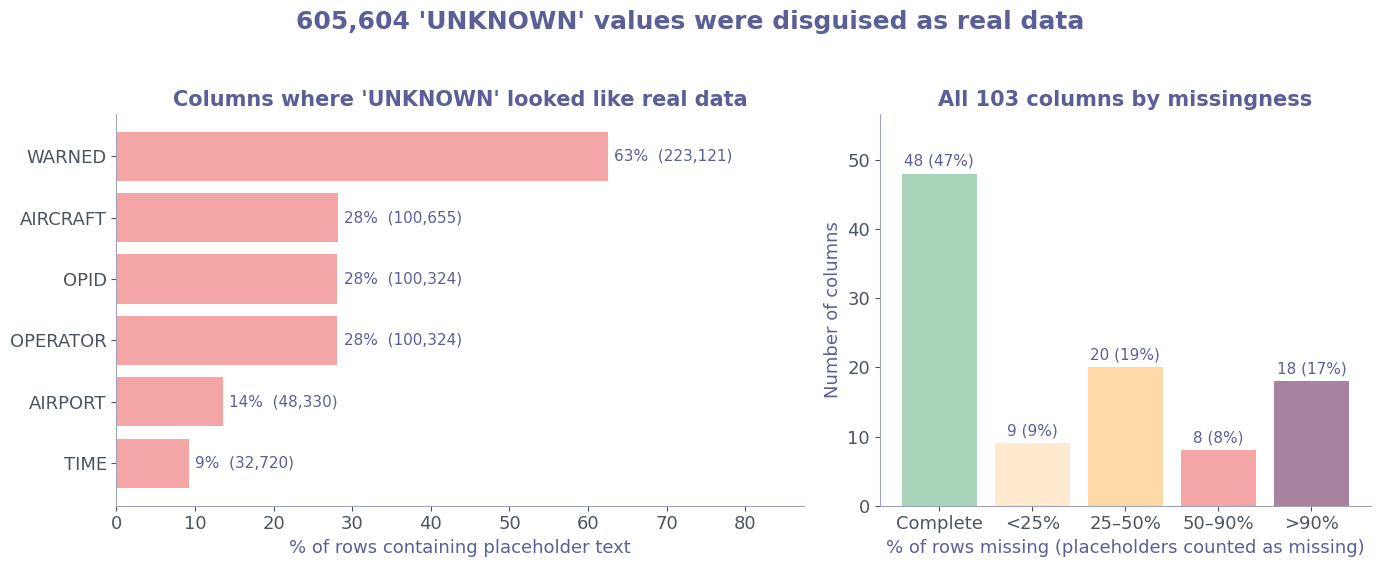

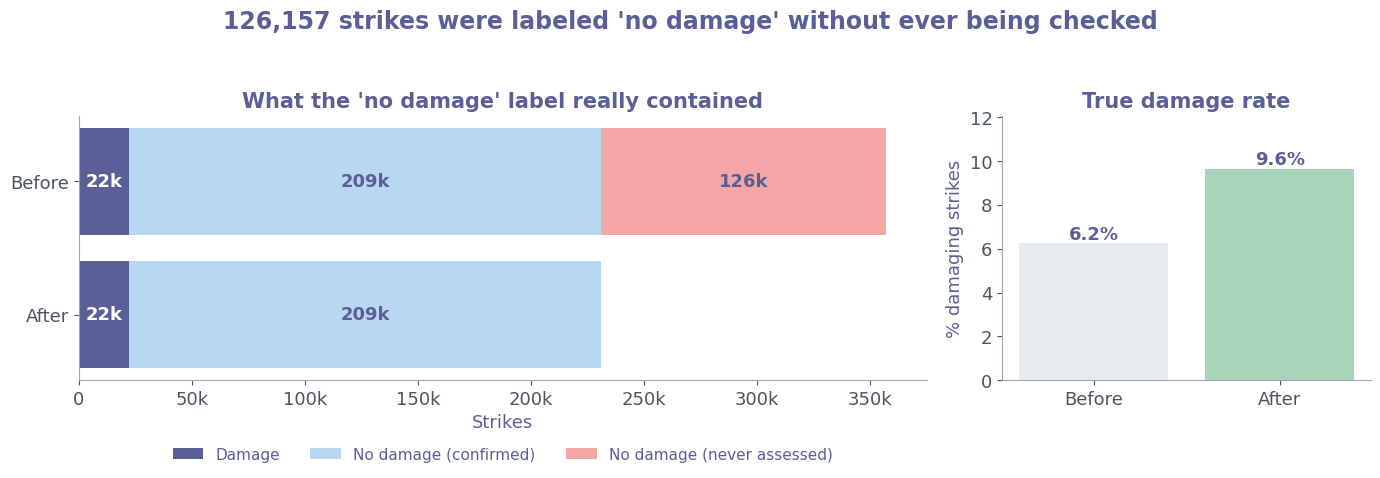

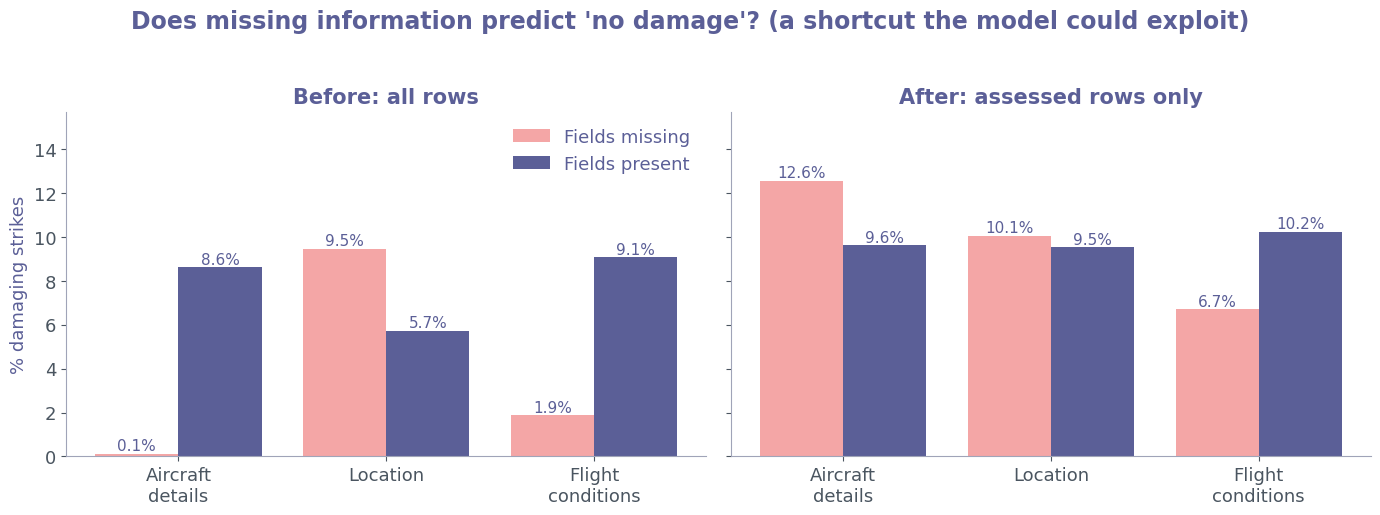

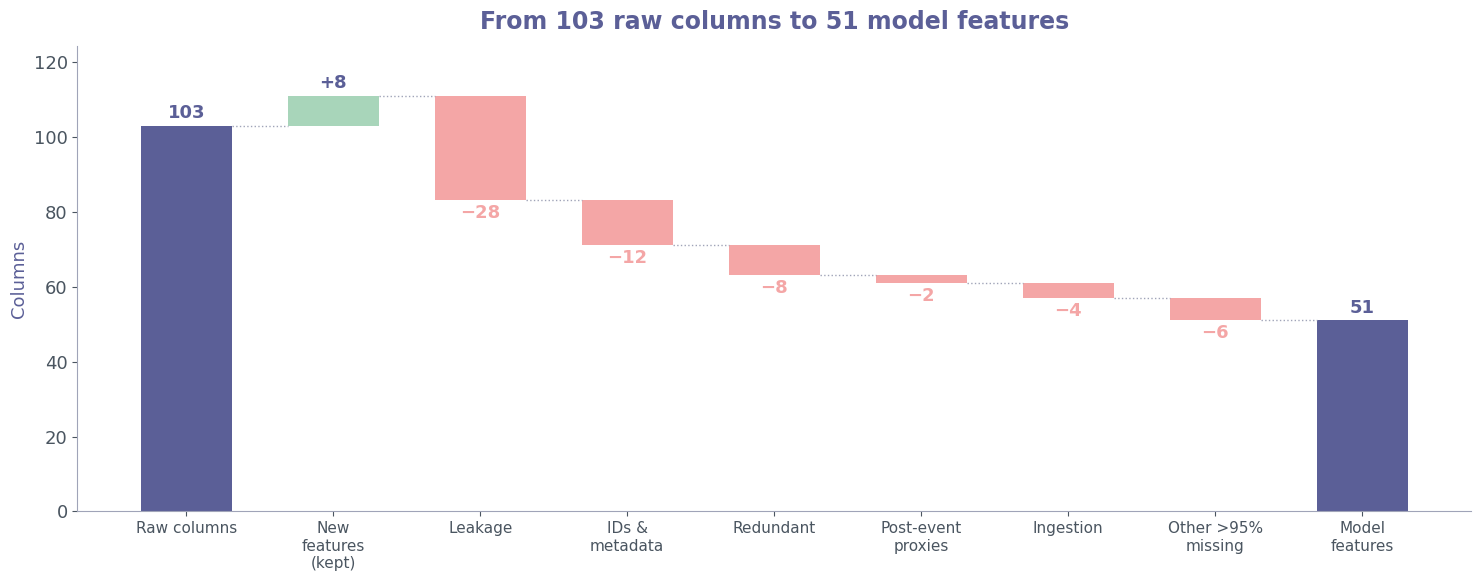

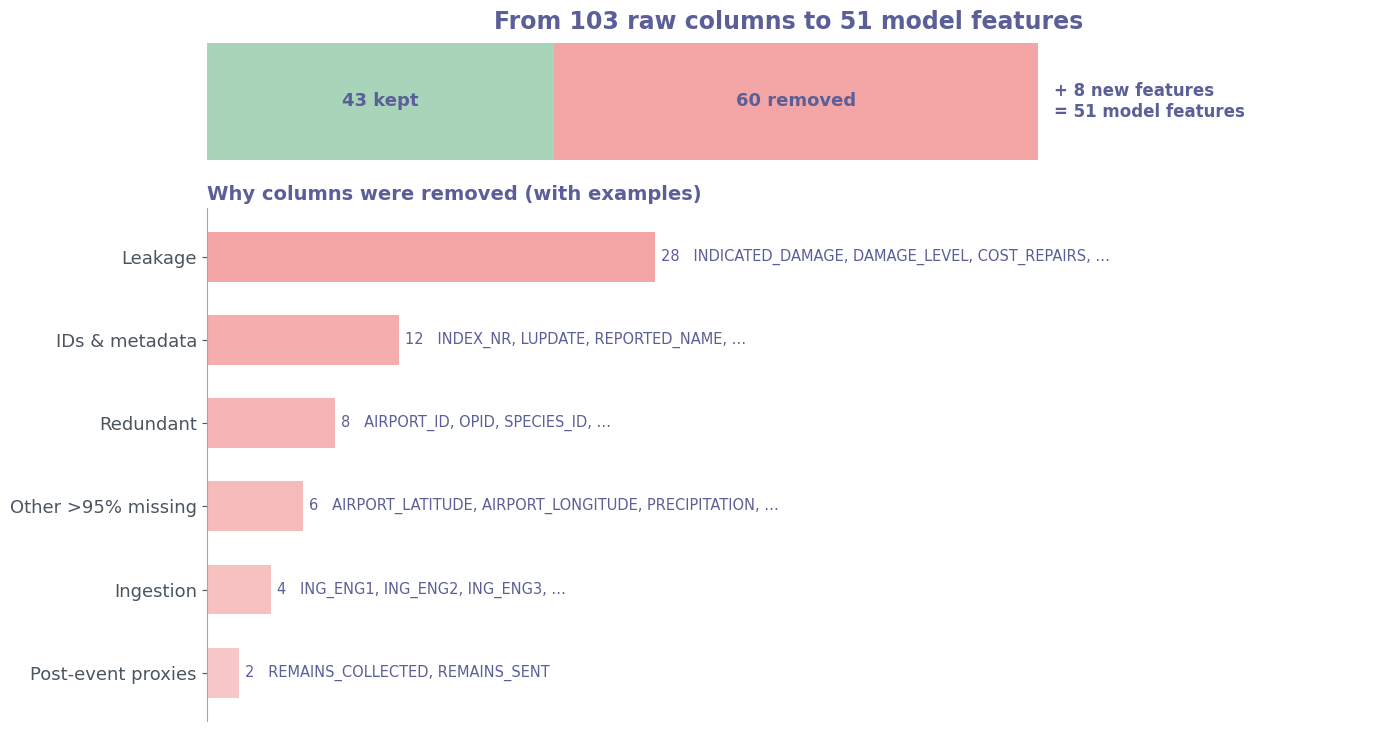

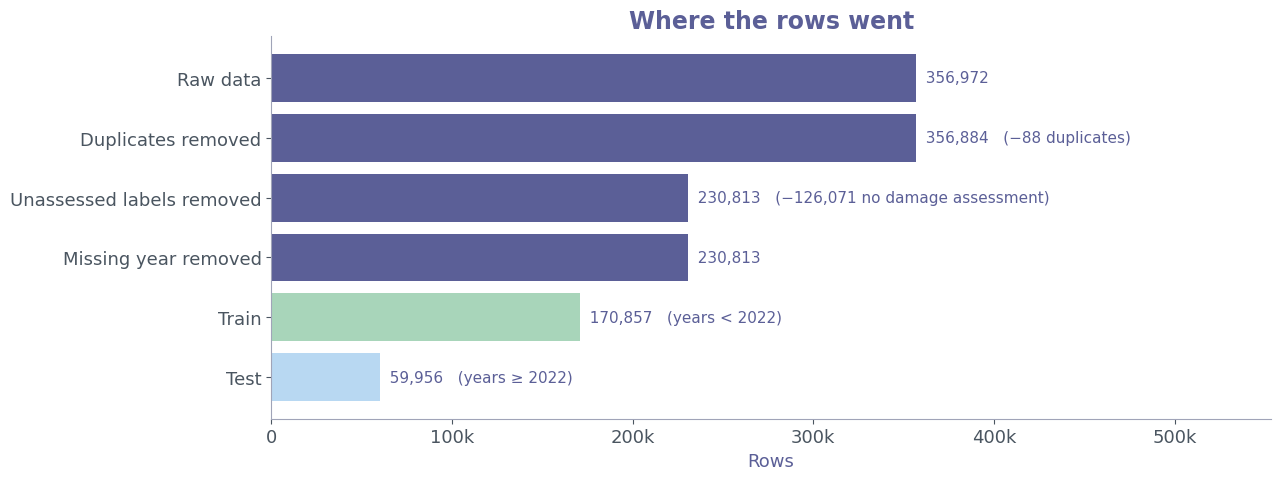

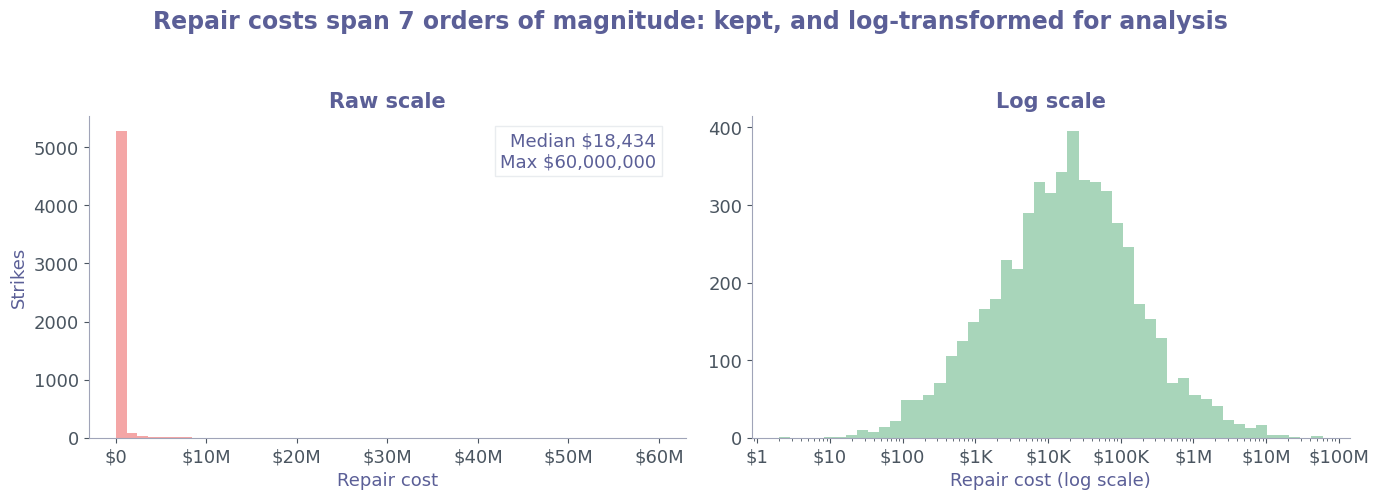

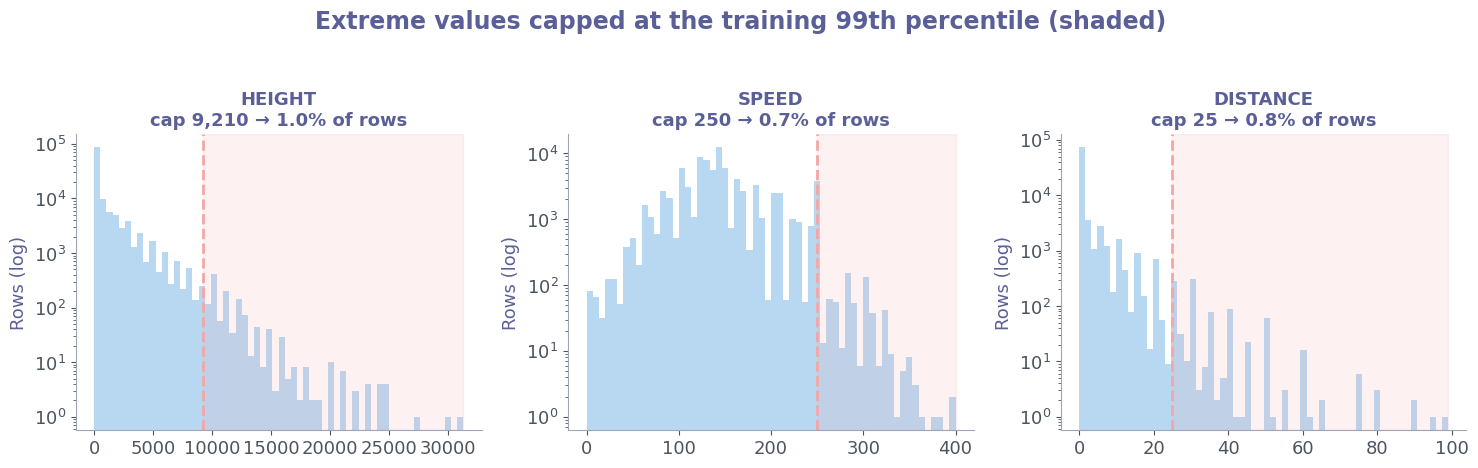

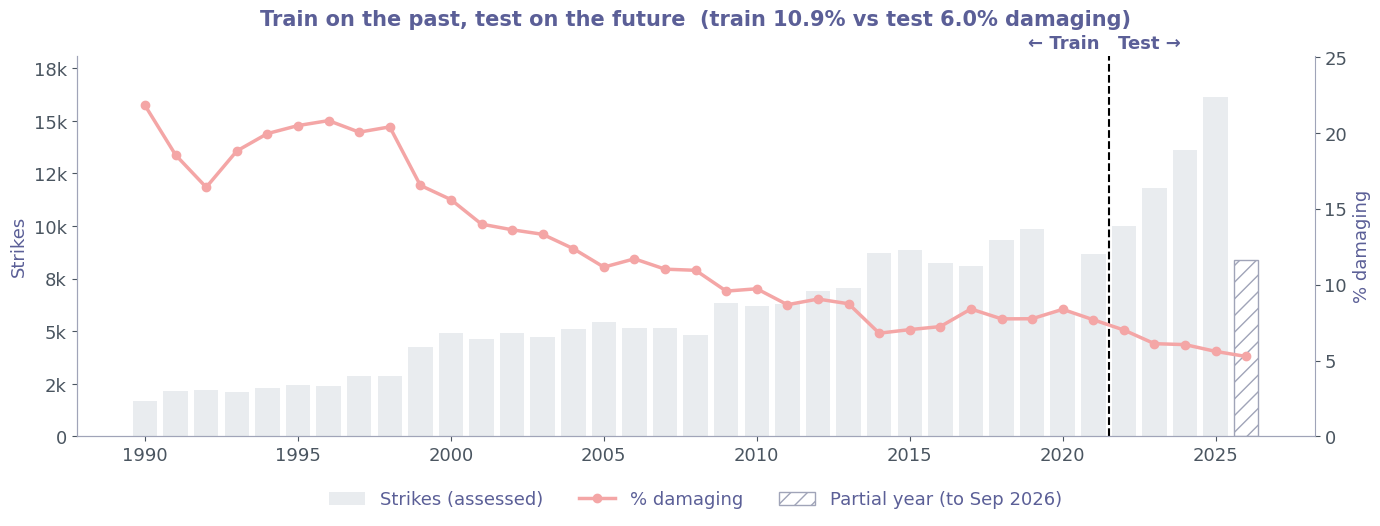

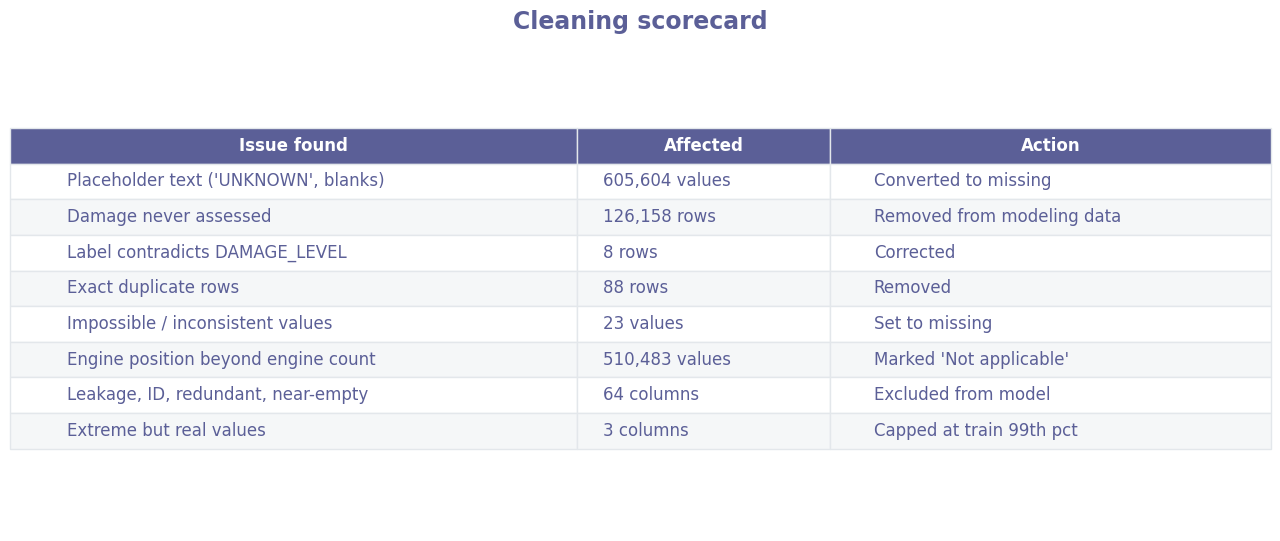

In [24]:
# ============================================================
# Presentation figures for the cleaning work
# Run AFTER cleaning_pipeline_v3.py (uses its variables).
# Saves high-resolution PNGs to slides_figs/ for your slides.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

SAVE_FIGS = False          # set True to also save PNGs to slides_figs/
OUT = "slides_figs"
if SAVE_FIGS:
    os.makedirs(OUT, exist_ok=True)

# ------------------------------------------------------------
# Color themes: change THEME to try a different look.
# Roles: dark = totals/text, keep = kept/fixed, problem = issues/removed,
#        warn = in-between, light = secondary bars, grey/muted = background
# ------------------------------------------------------------
THEME = "macaron"

PALETTES = {
    # ---- Pastel themes ----
    # Mint, rose and peach with a soft indigo for text and totals
    "macaron": dict(dark="#5B5F97", keep="#A8D5BA", problem="#F4A6A6", warn="#FFD8A8",
                    light="#B8D8F2", grey="#E9ECEF", muted="#A0A4B8"),
    # Aqua, salmon and lemon with mauve and lavender
    "sorbet":  dict(dark="#6D597A", keep="#9ED9CC", problem="#F7A399", warn="#FBE3A1",
                    light="#C9B6E4", grey="#EEE9F1", muted="#A99BB3"),
    # Sage, blossom pink and butter yellow
    "spring":  dict(dark="#52796F", keep="#A3C9A8", problem="#E8A0BF", warn="#F9D8A0",
                    light="#BFD7EA", grey="#EDF2EE", muted="#9AAFA6"),
    # Powder blue, bubblegum pink and lilac with a slate grey
    "cotton":  dict(dark="#4F5D75", keep="#9BD0E6", problem="#F5B0CB", warn="#FCE1A4",
                    light="#CDB4DB", grey="#ECEEF3", muted="#9AA3B5"),
    # ---- Bolder themes ----
    # Deep navy + ocean blue with bright orange accents (colorblind-friendly)
    "ocean":   dict(dark="#023047", keep="#219EBC", problem="#FB8500", warn="#FFB703",
                    light="#8ECAE6", grey="#D6DEE3", muted="#8A9BA8"),
    # Dusky indigo, jade and rose
    "indigo":  dict(dark="#2D3047", keep="#419D78", problem="#E0607E", warn="#EFB366",
                    light="#A3BCE2", grey="#DCDFE8", muted="#8E91A6"),
    # Muted Scandinavian tones
    "nordic":  dict(dark="#2E3440", keep="#7FA87A", problem="#BF616A", warn="#EBCB8B",
                    light="#88C0D0", grey="#D8DEE9", muted="#8F98A8"),
    # Plum, sage and gold
    "plum":    dict(dark="#3D2C4E", keep="#6A9C89", problem="#C8506A", warn="#E8B04B",
                    light="#B8C5D6", grey="#E2DDE8", muted="#9A8FA6"),
    # Previous theme: navy, teal, coral
    "coastal": dict(dark="#264653", keep="#2A9D8F", problem="#E76F51", warn="#F4A261",
                    light="#8ECAE6", grey="#D3D9DE", muted="#8A959E"),
}

_p = PALETTES[THEME]
DARK, GREEN, RED = _p["dark"], _p["keep"], _p["problem"]
AMBER, BLUE, GREY, MUTED = _p["warn"], _p["light"], _p["grey"], _p["muted"]
LIGHT_RED = tuple(0.3 * a + 0.7 for a in __import__("matplotlib.colors", fromlist=["to_rgb"]).to_rgb(RED))


def ink(color):
    """Dark text on light (pastel) fills, white text on dark fills."""
    from matplotlib.colors import to_rgb
    r, g, b = to_rgb(color)
    return DARK if 0.299 * r + 0.587 * g + 0.114 * b > 0.6 else "white"
plt.rcParams.update({
    "font.size": 13, "axes.titlesize": 15, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": DARK, "axes.labelcolor": DARK, "axes.titlecolor": DARK,
    "axes.edgecolor": MUTED, "xtick.color": "#4A5560", "ytick.color": "#4A5560",
})
thousands = FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k" if x >= 1000 else f"{x:,.0f}")


def save(fig, name):
    fig.tight_layout()
    if SAVE_FIGS:
        fig.savefig(f"{OUT}/{name}.png", dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()


raw = df.copy()
raw.columns = raw.columns.str.strip().str.upper()
n_raw = len(raw)

# Label pieces used by several slides
ind = pd.to_numeric(raw["INDICATED_DAMAGE"], errors="coerce")
lvl = raw["DAMAGE_LEVEL"].astype("string").str.strip().str.upper()
assessed = lvl.isin(["N", "M", "M?", "S", "D"]).fillna(False)
dmg_after = lvl.isin(["M", "M?", "S", "D"]).fillna(False)


# ------------------------------------------------------------
# Slide 1: Missing data was hidden as "UNKNOWN"
# ------------------------------------------------------------
ph = pd.Series(placeholder_by_col).sort_values(ascending=False)
ph = ph[ph / n_raw >= 0.01].head(8)        # hide columns where placeholders are negligible
ph_pct = ph / n_raw * 100

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.4, 1]})
bars = a1.barh(ph_pct.index[::-1], ph_pct.values[::-1], color=RED)
for rect, v, n in zip(bars, ph_pct.values[::-1], ph.values[::-1]):
    a1.text(rect.get_width() + 0.8, rect.get_y() + rect.get_height() / 2, f"{v:.0f}%  ({n:,})",
            va="center", fontsize=11)
a1.set_xlim(0, ph_pct.max() * 1.4)
a1.set_xlabel("% of rows containing placeholder text")
a1.set_title("Columns where 'UNKNOWN' looked like real data")

# Missingness in the ORIGINAL data, counting placeholder text as missing (before any other fixes)
pf = {}
for c in raw.columns:
    m = raw[c].isna()
    if raw[c].dtype == object or str(raw[c].dtype) in ("string", "category"):
        m = m | raw[c].astype("string").str.strip().str.upper().isin(PLACEHOLDERS).fillna(False)
    pf[c] = m.mean() * 100
pf = pd.Series(pf)

labels = ["Complete", "<25%", "25–50%", "50–90%", ">90%"]
counts = pd.cut(pf, bins=[-0.01, 0, 25, 50, 90, 100], labels=labels).value_counts().reindex(labels, fill_value=0)
from matplotlib.colors import to_rgb


def mix(c1, c2, t):
    a, b_ = to_rgb(c1), to_rgb(c2)
    return tuple((1 - t) * x + t * y for x, y in zip(a, b_))


# Four clearly separated steps: pale -> warning -> problem -> deep problem
_steps = [mix(AMBER, "white", 0.45), AMBER, RED, mix(RED, DARK, 0.5)]
b = a2.bar(labels, counts, color=[GREEN, *_steps])
for rect, n in zip(b, counts):
    a2.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + counts.max() * 0.015,
            f"{n} ({n / len(pf) * 100:.0f}%)", ha="center", va="bottom", fontsize=11)
a2.set_ylim(0, counts.max() * 1.18)
a2.set_ylabel("Number of columns")
a2.set_xlabel("% of rows missing (placeholders counted as missing)")
a2.set_title(f"All {len(pf)} columns by missingness")

fig.suptitle(f"{placeholder_total:,} 'UNKNOWN' values were disguised as real data", fontsize=18, fontweight="bold", y=1.03)
save(fig, "01_hidden_missing")


# ------------------------------------------------------------
# Slide 2: The label problem
# ------------------------------------------------------------
before = {"Damage": int((ind == 1).sum()),
          "No damage (confirmed)": int(((ind == 0) & assessed).sum()),
          "No damage (never assessed)": int(((ind == 0) & ~assessed).sum())}
after = {"Damage": int(dmg_after.sum()),
         "No damage (confirmed)": int((lvl == "N").fillna(False).sum()),
         "No damage (never assessed)": 0}
colors = {"Damage": DARK, "No damage (confirmed)": BLUE, "No damage (never assessed)": RED}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [2.3, 1]})
left = np.zeros(2)
for cat in before:
    vals = np.array([before[cat], after[cat]])
    a1.barh(["Before", "After"], vals, left=left, color=colors[cat], label=cat)
    for i, v in enumerate(vals):
        if v > n_raw * 0.06:
            a1.text(left[i] + v / 2, i, f"{v / 1000:,.0f}k", ha="center", va="center", fontweight="bold",
                    color=ink(colors[cat]))
    left += vals
a1.invert_yaxis()
a1.xaxis.set_major_formatter(thousands)
a1.set_xlabel("Strikes")
a1.set_title("What the 'no damage' label really contained")
a1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=11)

rate_before = ind.mean() * 100
rate_after = dmg_after.sum() / assessed.sum() * 100
rb = a2.bar(["Before", "After"], [rate_before, rate_after], color=[GREY, GREEN])
for rect, v in zip(rb, [rate_before, rate_after]):
    a2.text(rect.get_x() + rect.get_width() / 2, v, f"{v:.1f}%", ha="center", va="bottom", fontweight="bold")
a2.set_ylim(0, max(rate_before, rate_after) * 1.25)
a2.set_ylabel("% damaging strikes")
a2.set_title("True damage rate")

fig.suptitle(f"{before['No damage (never assessed)']:,} strikes were labeled 'no damage' without ever being checked",
             fontsize=17, fontweight="bold", y=1.04)
save(fig, "02_label_problem")


# ------------------------------------------------------------
# Slide 3: Missingness as a shortcut (before vs after the label fix)
# ------------------------------------------------------------
groups = {"Aircraft\ndetails": ["AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS", "ENG_1_POS"],
          "Location": ["STATE", "FAAREGION"],
          "Flight\nconditions": ["HEIGHT", "SPEED", "PHASE_OF_FLIGHT"]}
rows = []
for name, cols in groups.items():
    cols = [c for c in cols if c in raw.columns]
    allm = raw[cols].isna().all(axis=1)
    a_m, a_p = allm & assessed, ~allm & assessed
    rows.append({"group": name,
                 "b_miss": ind[allm].mean() * 100, "b_pres": ind[~allm].mean() * 100,
                 "a_miss": dmg_after[a_m].mean() * 100 if a_m.any() else np.nan,
                 "a_pres": dmg_after[a_p].mean() * 100})
sc = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(len(sc))
ymax = np.nanmax(sc[["b_miss", "b_pres", "a_miss", "a_pres"]].values) * 1.25
for ax, (miss, pres, title) in zip(axes, [("b_miss", "b_pres", "Before: all rows"),
                                          ("a_miss", "a_pres", "After: assessed rows only")]):
    b1 = ax.bar(x - 0.2, sc[miss], 0.4, color=RED, label="Fields missing")
    b2 = ax.bar(x + 0.2, sc[pres], 0.4, color=DARK, label="Fields present")
    for rect in list(b1) + list(b2):
        h = rect.get_height()
        if not np.isnan(h):
            ax.text(rect.get_x() + rect.get_width() / 2, h, f"{h:.1f}%", ha="center", va="bottom", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(sc["group"])
    ax.set_ylim(0, ymax)
    ax.set_title(title)
axes[0].set_ylabel("% damaging strikes")
axes[0].legend(frameon=False)
fig.suptitle("Does missing information predict 'no damage'? (a shortcut the model could exploit)",
             fontsize=17, fontweight="bold", y=1.03)
save(fig, "03_missingness_shortcut")


# ------------------------------------------------------------
# Slide 4: Column waterfall (103 raw columns -> model features)
# ------------------------------------------------------------
import textwrap

# Count only ORIGINAL columns as drops, and only derived columns that are KEPT as additions,
# so EDA-only helper columns (LOG_ costs, COST_REVIEW_FLAG) aren't added and then removed.
assigned = {}
for grp, cols in drop_groups.items():
    for c in cols:
        if c in drop_cols and c in raw.columns and c not in assigned:
            assigned[c] = grp
drop_counts = pd.Series(assigned, dtype="object").value_counts().reindex(list(drop_groups)).fillna(0).astype(int)
derived_kept = [c for c in clean_df.columns
                if c not in raw.columns and c != "DAMAGE_TARGET" and c not in drop_cols]
n_features = model_df.shape[1] - 1

nice = {"leakage": "Leakage", "identifiers/metadata": "IDs & metadata", "redundant": "Redundant",
        "post-event proxies": "Post-event proxies", "ingestion": "Ingestion",
        f">{NEAR_EMPTY_PCT}% missing": f"Other >{NEAR_EMPTY_PCT}% missing"}


def wrap(text, width=11):
    return "\n".join(textwrap.wrap(text, width))


steps = ([("Raw columns", original_shape[1], "total"),
          ("New features (kept)", len(derived_kept), "add")]
         + [(nice.get(grp, grp), -n, "sub") for grp, n in drop_counts.items() if n]
         + [("Model features", n_features, "total")])

fig, ax = plt.subplots(figsize=(15, 6))
running, top = 0, 0
for i, (label, val, kind) in enumerate(steps):
    if kind == "total":
        bottom, height, color, running = 0, val, DARK, val
    elif kind == "add":
        bottom, height, color = running, val, GREEN
        running += val
    else:
        running += val
        bottom, height, color = running, -val, RED
    ax.bar(i, height, bottom=bottom, color=color, width=0.62)
    top = max(top, bottom + height)

    if kind == "sub":   # label below a removal so it isn't confused with the previous bar
        ax.text(i, bottom - 1, f"−{-val}", ha="center", va="top", fontweight="bold", color=RED)
    else:
        ax.text(i, bottom + height + 1, f"{val:+}" if kind == "add" else f"{val}",
                ha="center", va="bottom", fontweight="bold")

    if i < len(steps) - 1:   # connector to the next bar
        ax.plot([i + 0.31, i + 0.69], [running, running], color=MUTED, lw=1, ls=":")

ax.set_ylim(0, top * 1.12)
ax.set_xticks(range(len(steps)))
ax.set_xticklabels([wrap(s[0]) for s in steps], fontsize=11)
ax.set_ylabel("Columns")
ax.set_title(f"From {original_shape[1]} raw columns to {n_features} model features", fontsize=17, pad=12)
if running != n_features:
    print(f"Warning: waterfall ends at {running}, but model has {n_features} features")
save(fig, "04_column_waterfall")


# ------------------------------------------------------------
# Slide 4b (alternative to the waterfall): why columns were removed
# Top: kept vs removed. Bottom: reasons ranked, with example columns.
# ------------------------------------------------------------
examples = {}
for c, grp in assigned.items():
    examples.setdefault(grp, []).append(c)
reasons = drop_counts[drop_counts > 0].sort_values()
removed = int(reasons.sum())
kept_orig = original_shape[1] - removed

fig, (top_ax, ax) = plt.subplots(2, 1, figsize=(14, 7.5), gridspec_kw={"height_ratios": [1, 4]})

# Top: one bar for the 103 raw columns
top_ax.barh([0], [kept_orig], color=GREEN, height=0.6)
top_ax.barh([0], [removed], left=kept_orig, color=RED, height=0.6)
top_ax.text(kept_orig / 2, 0, f"{kept_orig} kept", ha="center", va="center", color=ink(GREEN), fontweight="bold")
top_ax.text(kept_orig + removed / 2, 0, f"{removed} removed", ha="center", va="center", color=ink(RED), fontweight="bold")
top_ax.text(original_shape[1] + 2, 0, f"+ {len(derived_kept)} new features\n= {n_features} model features",
            va="center", fontsize=12, fontweight="bold", color=DARK)
top_ax.set_xlim(0, original_shape[1] * 1.4)
top_ax.axis("off")
top_ax.set_title(f"From {original_shape[1]} raw columns to {n_features} model features", fontsize=17)

# Bottom: reasons, largest at top, with example column names
from matplotlib.colors import LinearSegmentedColormap

shade = LinearSegmentedColormap.from_list("removal", [LIGHT_RED, RED])
bars = ax.barh([nice.get(r, r) for r in reasons.index], reasons.values,
               color=shade(np.linspace(0.45, 1, len(reasons))), height=0.6)
for rect, grp in zip(bars, reasons.index):
    n = int(rect.get_width())
    ex = examples.get(grp, [])
    ex_txt = ", ".join(ex[:3]) + (", …" if len(ex) > 3 else "")
    ax.text(rect.get_width() + 0.4, rect.get_y() + rect.get_height() / 2,
            f"{n}   {ex_txt}", va="center", fontsize=10.5)
ax.set_xlim(0, reasons.max() * 2.6)
ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
ax.set_title("Why columns were removed (with examples)", fontsize=14, loc="left")
save(fig, "04b_column_reasons")


# ------------------------------------------------------------
# Slide 5: Row funnel
# ------------------------------------------------------------
stages = [("Raw data", original_shape[0], None),
          ("Duplicates removed", original_shape[0] - dup_count, f"−{dup_count:,} duplicates"),
          ("Unassessed labels removed", original_shape[0] - dup_count - no_target, f"−{no_target:,} no damage assessment"),
          ("Missing year removed", len(model_df), f"−{no_year:,}" if no_year else None),
          ("Train", len(train_df), f"years < {TEST_START_YEAR}"),
          ("Test", len(test_df), f"years ≥ {TEST_START_YEAR}")]

fig, ax = plt.subplots(figsize=(13, 5))
names = [s[0] for s in stages][::-1]
vals = [s[1] for s in stages][::-1]
notes = [s[2] for s in stages][::-1]
cols = [BLUE, GREEN] + [DARK] * (len(stages) - 2)
bars = ax.barh(names, vals, color=cols)
for rect, v, note in zip(bars, vals, notes):
    ax.text(rect.get_width(), rect.get_y() + rect.get_height() / 2,
            f"  {v:,}" + (f"   ({note})" if note else ""), va="center", fontsize=11)
ax.set_xlim(0, max(vals) * 1.55)
ax.xaxis.set_major_formatter(thousands)
ax.set_xlabel("Rows")
ax.set_title("Where the rows went", fontsize=17)
save(fig, "05_row_funnel")


# ------------------------------------------------------------
# Slide 6: Skewed costs (EDA)
# ------------------------------------------------------------
def money(x, _=None):
    return f"${x / 1e6:g}M" if x >= 1e6 else (f"${x / 1e3:g}K" if x >= 1e3 else f"${x:g}")


c = "COST_REPAIRS_INFL_ADJ"
if c in clean_df.columns:
    vals = clean_df.loc[clean_df[c] > 0, c].astype(float)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8))
    a1.hist(vals, bins=50, color=RED)
    a1.xaxis.set_major_formatter(FuncFormatter(money))
    a1.set_title("Raw scale")
    a1.set_xlabel("Repair cost")
    a1.set_ylabel("Strikes")
    a1.text(0.95, 0.95, f"Median ${vals.median():,.0f}\nMax ${vals.max():,.0f}",
            transform=a1.transAxes, ha="right", va="top", bbox=dict(fc="white", ec=GREY))
    a2.hist(vals, bins=np.logspace(np.log10(vals.min()), np.log10(vals.max()), 50), color=GREEN)
    a2.set_xscale("log")
    a2.xaxis.set_major_formatter(FuncFormatter(money))
    a2.set_title("Log scale")
    a2.set_xlabel("Repair cost (log scale)")
    fig.suptitle("Repair costs span 7 orders of magnitude: kept, and log-transformed for analysis",
                 fontsize=17, fontweight="bold", y=1.04)
    save(fig, "06_cost_skew")


# ------------------------------------------------------------
# Slide 7: Capping extreme values (fit on training data only)
# ------------------------------------------------------------
cap_cols = [c for c in ["HEIGHT", "SPEED", "DISTANCE"] if c in caps]
pre_train = model_df[model_df[year_col] < TEST_START_YEAR]
fig, axes = plt.subplots(1, len(cap_cols), figsize=(5 * len(cap_cols), 4.5), squeeze=False)
for ax, c in zip(axes[0], cap_cols):
    pre = pre_train[c].dropna().astype(float)
    hi = caps[c][1]
    ax.hist(pre, bins=60, color=BLUE)
    ax.set_yscale("log")
    ax.axvspan(hi, pre.max(), color=RED, alpha=0.15)
    ax.axvline(hi, color=RED, ls="--", lw=2)
    ax.set_title(f"{c}\ncap {hi:,.0f} → {(pre > hi).mean() * 100:.1f}% of rows", fontsize=13)
    ax.set_ylabel("Rows (log)")
fig.suptitle("Extreme values capped at the training 99th percentile (shaded)", fontsize=17, fontweight="bold", y=1.04)
save(fig, "07_capping")


# ------------------------------------------------------------
# Slide 8: Time-based split and class balance
# ------------------------------------------------------------
from matplotlib.patches import Patch

by_year = model_df.groupby(year_col)["DAMAGE_TARGET"].agg(rate="mean", n="size").reset_index()
by_year[year_col] = by_year[year_col].astype(int)

fig, ax1 = plt.subplots(figsize=(14, 5.5))
bars = ax1.bar(by_year[year_col], by_year["n"], color=GREY, label="Strikes (assessed)")
ax1.set_ylim(0, by_year["n"].max() * 1.12)
ax1.yaxis.set_major_formatter(thousands)
ax1.set_ylabel("Strikes")
extra = []
last = clean_df["INCIDENT_DATE"].max()
if pd.notna(last) and last.year == by_year[year_col].max() and (last.month, last.day) != (12, 31):
    bars[-1].set_facecolor("white")
    bars[-1].set_edgecolor(MUTED)
    bars[-1].set_hatch("//")
    extra.append(Patch(facecolor="white", edgecolor=MUTED, hatch="//", label=f"Partial year (to {last:%b %Y})"))
ax2 = ax1.twinx()
ax2.plot(by_year[year_col], by_year["rate"] * 100, color=RED, marker="o", lw=2.5, label="% damaging")
ax2.set_ylim(0, by_year["rate"].max() * 100 * 1.15)
ax2.set_ylabel("% damaging")
ax2.spines["right"].set_visible(True)
split = TEST_START_YEAR - 0.5
ax1.axvline(split, ls="--", color="black")
tr = ax1.get_xaxis_transform()
ax1.text(split - 0.3, 1.01, "← Train", ha="right", va="bottom", transform=tr, fontweight="bold")
ax1.text(split + 0.3, 1.01, "Test →", ha="left", va="bottom", transform=tr, fontweight="bold")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2 + extra, l1 + l2 + [e.get_label() for e in extra],
           loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
ax1.set_title(f"Train on the past, test on the future  "
              f"(train {train_df['DAMAGE_TARGET'].mean() * 100:.1f}% vs test {test_df['DAMAGE_TARGET'].mean() * 100:.1f}% damaging)",
              fontsize=15, pad=22)
save(fig, "08_time_split")


# ------------------------------------------------------------
# Slide 9: Cleaning scorecard (summary table)
# ------------------------------------------------------------
g = globals()
score = [
    ("Placeholder text ('UNKNOWN', blanks)", f"{placeholder_total:,} values", "Converted to missing"),
    ("Damage never assessed", f"{g.get('unassessed', 0):,} rows", "Removed from modeling data"),
    ("Label contradicts DAMAGE_LEVEL", f"{g.get('corrected', 0):,} rows", "Corrected"),
    ("Exact duplicate rows", f"{dup_count:,} rows", "Removed"),
    ("Impossible / inconsistent values", f"{sum(impossible.values()):,} values", "Set to missing"),
    ("Engine position beyond engine count", f"{g.get('na_filled', 0):,} values", "Marked 'Not applicable'"),
    ("Leakage, ID, redundant, near-empty", f"{len(drop_cols)} columns", "Excluded from model"),
    ("Extreme but real values", f"{len(caps)} columns", "Capped at train 99th pct"),
]
fig, ax = plt.subplots(figsize=(13, 0.55 * len(score) + 1.2))
ax.axis("off")
tbl = ax.table(cellText=score, colLabels=["Issue found", "Affected", "Action"],
               colWidths=[0.45, 0.2, 0.35], loc="center", cellLoc="left")
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1, 1.9)
for (r, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#E3E7EB")
    if r == 0:
        cell.set_facecolor(DARK)
        cell.set_text_props(color=ink(DARK), fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#F5F7F8")
ax.set_title("Cleaning scorecard", fontsize=17, pad=12)
save(fig, "09_scorecard")

if SAVE_FIGS:
    print(f"Saved {len(os.listdir(OUT))} figures to {OUT}/")

In [25]:
clean_df.to_csv("clean_wildlife.csv", index=False)